In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
!pip install opencv-python pillow seaborn scikit-learn tqdm -q

In [4]:
import os
import cv2
import json
import random
import shutil
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path
from PIL import Image
from tqdm import tqdm

import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import MobileNetV2, ResNet50
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    precision_recall_curve
)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

ALOPECIA_DIR = "/content/drive/MyDrive/Capstone Project/Alopecia"
NORMAL_DIR = "/content/drive/MyDrive/Capstone Project/Normal"

BASE_DIR = "/content/drive/MyDrive/Alopecia_Project"
OUTPUT_DIR = f"{BASE_DIR}/outputs"
MODEL_DIR = f"{OUTPUT_DIR}/models"
FIGURE_DIR = f"{OUTPUT_DIR}/figures"
METRIC_DIR = f"{OUTPUT_DIR}/metrics"

for d in [OUTPUT_DIR, MODEL_DIR, FIGURE_DIR, METRIC_DIR]:
    os.makedirs(d, exist_ok=True)

print("TensorFlow version:", tf.__version__)
print("GPU available:", tf.config.list_physical_devices('GPU'))

TensorFlow version: 2.19.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [5]:
print("Alopecia path exists:", os.path.exists(ALOPECIA_DIR))
print("Normal path exists:", os.path.exists(NORMAL_DIR))

if not os.path.exists(ALOPECIA_DIR):
    raise FileNotFoundError("Alopecia folder not found. Check Google Drive path.")

if not os.path.exists(NORMAL_DIR):
    raise FileNotFoundError("Normal folder not found. Check Google Drive path.")

Alopecia path exists: True
Normal path exists: True


In [6]:
VALID_EXTENSIONS = {".jpg", ".jpeg", ".png", ".bmp", ".webp", ".tif", ".tiff"}

def is_valid_image(path):
    try:
        img = Image.open(path)
        img.verify()
        return True
    except:
        return False

def collect_images(folder, label):
    records = []

    for file in os.listdir(folder):
        path = os.path.join(folder, file)

        if not os.path.isfile(path):
            continue

        ext = Path(file).suffix.lower()

        if ext not in VALID_EXTENSIONS:
            continue

        valid = is_valid_image(path)

        if valid:
            try:
                img = Image.open(path)
                width, height = img.size
            except:
                width, height = None, None

            records.append({
                "path": path,
                "filename": file,
                "label": label,
                "width": width,
                "height": height,
                "extension": ext
            })

    return records

alopecia_records = collect_images(ALOPECIA_DIR, "alopecia")
normal_records = collect_images(NORMAL_DIR, "normal")

df = pd.DataFrame(alopecia_records + normal_records)

print(df.head())
print("\nDataset size:", len(df))
print(df["label"].value_counts())

                                                path  \
0  /content/drive/MyDrive/Capstone Project/Alopec...   
1  /content/drive/MyDrive/Capstone Project/Alopec...   
2  /content/drive/MyDrive/Capstone Project/Alopec...   
3  /content/drive/MyDrive/Capstone Project/Alopec...   
4  /content/drive/MyDrive/Capstone Project/Alopec...   

                                          filename     label  width  height  \
0  WhatsApp Image 2026-02-11 at 14.13.28 (11).jpeg  alopecia    960    1280   
1   WhatsApp Image 2026-02-11 at 14.13.28 (3).jpeg  alopecia    960    1280   
2   WhatsApp Image 2026-02-11 at 14.13.28 (1).jpeg  alopecia    960    1280   
3   WhatsApp Image 2026-02-11 at 14.13.28 (4).jpeg  alopecia    960    1280   
4   WhatsApp Image 2026-02-11 at 14.13.28 (2).jpeg  alopecia    960    1280   

  extension  
0     .jpeg  
1     .jpeg  
2     .jpeg  
3     .jpeg  
4     .jpeg  

Dataset size: 120
label
alopecia    60
normal      60
Name: count, dtype: int64


In [7]:
summary_path = f"{METRIC_DIR}/dataset_inventory.csv"
df.to_csv(summary_path, index=False)

print("Saved dataset inventory to:", summary_path)

Saved dataset inventory to: /content/drive/MyDrive/Alopecia_Project/outputs/metrics/dataset_inventory.csv


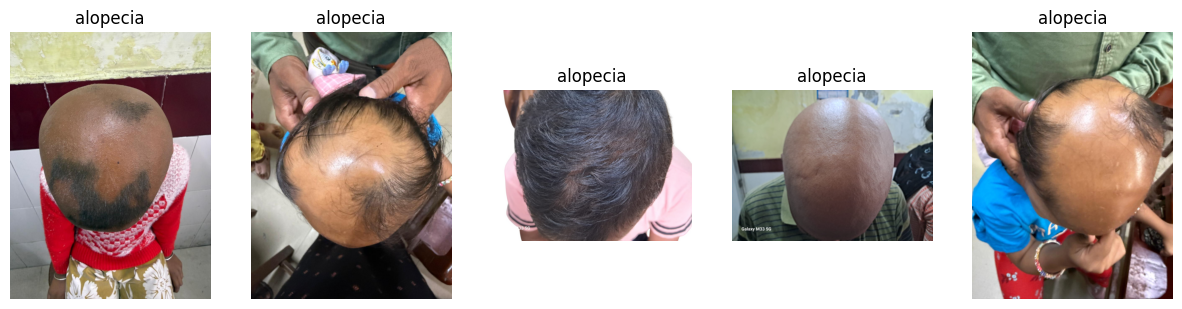

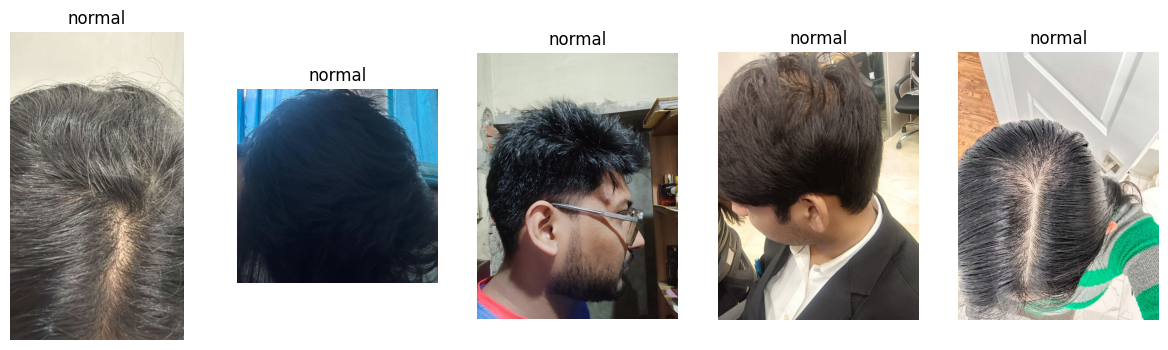

In [8]:
def show_samples(df, label, n=5):
    sample_df = df[df["label"] == label].sample(min(n, len(df[df["label"] == label])), random_state=SEED)

    plt.figure(figsize=(15, 4))

    for i, (_, row) in enumerate(sample_df.iterrows()):
        img = Image.open(row["path"]).convert("RGB")
        plt.subplot(1, n, i + 1)
        plt.imshow(img)
        plt.title(label)
        plt.axis("off")

    plt.show()

show_samples(df, "alopecia", 5)
show_samples(df, "normal", 5)

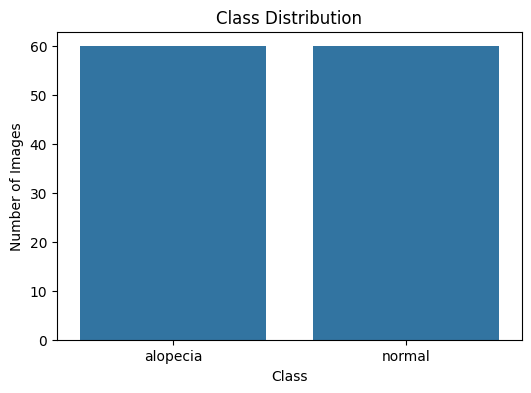

In [9]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x="label")
plt.title("Class Distribution")
plt.xlabel("Class")
plt.ylabel("Number of Images")
plt.show()

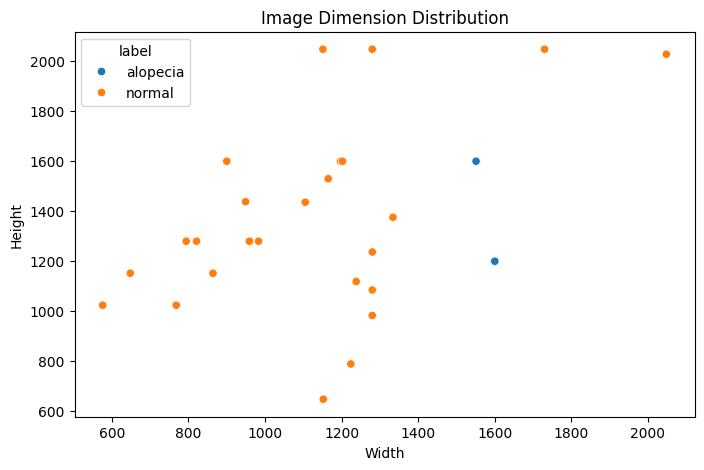

In [10]:
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x="width", y="height", hue="label")
plt.title("Image Dimension Distribution")
plt.xlabel("Width")
plt.ylabel("Height")
plt.show()

In [36]:
PATCH_SIZE = 224
STRIDE = 112

PATCH_DIR = f"{BASE_DIR}/processed_patches_filtered"

if os.path.exists(PATCH_DIR):
    shutil.rmtree(PATCH_DIR)

for split in ["train", "val", "test"]:
    for label in ["alopecia", "normal"]:
        os.makedirs(f"{PATCH_DIR}/{split}/{label}", exist_ok=True)

def is_good_patch(patch_np):
    gray = cv2.cvtColor(patch_np, cv2.COLOR_RGB2GRAY)

    brightness = gray.mean()
    contrast = gray.std()
    blur_score = cv2.Laplacian(gray, cv2.CV_64F).var()

    if brightness < 35 or brightness > 225:
        return False

    if contrast < 18:
        return False

    if blur_score < 25:
        return False

    return True

def extract_patches(image_path, output_folder, prefix, patch_size=224, stride=112):
    img = Image.open(image_path).convert("RGB")
    img_np = np.array(img)

    h, w, c = img_np.shape
    metadata = []
    patch_id = 0

    if h < patch_size or w < patch_size:
        resized = img.resize((patch_size, patch_size))
        patch_np = np.array(resized)

        save_name = f"{prefix}_patch_0.png"
        save_path = os.path.join(output_folder, save_name)
        resized.save(save_path)

        metadata.append({
            "patch_path": save_path,
            "original_path": image_path,
            "x": 0,
            "y": 0,
            "patch_id": patch_id
        })

        return metadata

    for y in range(0, h - patch_size + 1, stride):
        for x in range(0, w - patch_size + 1, stride):
            patch = img_np[y:y+patch_size, x:x+patch_size]

            if not is_good_patch(patch):
                continue

            save_name = f"{prefix}_patch_{patch_id}.png"
            save_path = os.path.join(output_folder, save_name)

            Image.fromarray(patch).save(save_path)

            metadata.append({
                "patch_path": save_path,
                "original_path": image_path,
                "x": x,
                "y": y,
                "patch_id": patch_id
            })

            patch_id += 1

    if patch_id == 0:
        resized = img.resize((patch_size, patch_size))
        save_name = f"{prefix}_patch_0.png"
        save_path = os.path.join(output_folder, save_name)
        resized.save(save_path)

        metadata.append({
            "patch_path": save_path,
            "original_path": image_path,
            "x": 0,
            "y": 0,
            "patch_id": 0
        })

    return metadata

patch_records = []

for _, row in tqdm(split_df.iterrows(), total=len(split_df)):
    split = row["split"]
    label = row["label"]
    image_path = row["path"]

    output_folder = f"{PATCH_DIR}/{split}/{label}"
    prefix = Path(row["filename"]).stem.replace(" ", "_")

    patches = extract_patches(
        image_path=image_path,
        output_folder=output_folder,
        prefix=f"{label}_{prefix}",
        patch_size=PATCH_SIZE,
        stride=STRIDE
    )

    for p in patches:
        p["split"] = split
        p["label"] = label
        patch_records.append(p)

patch_df = pd.DataFrame(patch_records)

patch_metadata_path = f"{METRIC_DIR}/patch_metadata_filtered.csv"
patch_df.to_csv(patch_metadata_path, index=False)

print("Total filtered patches:", len(patch_df))
print(pd.crosstab(patch_df["split"], patch_df["label"]))
print("Saved patch metadata:", patch_metadata_path)

100%|██████████| 120/120 [02:57<00:00,  1.48s/it]

Total filtered patches: 6124
label  alopecia  normal
split                  
test        646     422
train      2135    2213
val         338     370
Saved patch metadata: /content/drive/MyDrive/Alopecia_Project/outputs/metrics/patch_metadata_filtered.csv


In [12]:
PATCH_SIZE = 224
STRIDE = 112

PATCH_DIR = f"{BASE_DIR}/processed_patches"

if os.path.exists(PATCH_DIR):
    shutil.rmtree(PATCH_DIR)

for split in ["train", "val", "test"]:
    for label in ["alopecia", "normal"]:
        os.makedirs(f"{PATCH_DIR}/{split}/{label}", exist_ok=True)

def extract_patches(image_path, output_folder, prefix, patch_size=224, stride=112):
    img = Image.open(image_path).convert("RGB")
    img_np = np.array(img)

    h, w, c = img_np.shape
    metadata = []
    patch_id = 0

    if h < patch_size or w < patch_size:
        resized = img.resize((patch_size, patch_size))
        save_name = f"{prefix}_patch_0.png"
        save_path = os.path.join(output_folder, save_name)
        resized.save(save_path)

        metadata.append({
            "patch_path": save_path,
            "original_path": image_path,
            "x": 0,
            "y": 0,
            "patch_id": patch_id
        })

        return metadata

    for y in range(0, h - patch_size + 1, stride):
        for x in range(0, w - patch_size + 1, stride):
            patch = img_np[y:y+patch_size, x:x+patch_size]

            save_name = f"{prefix}_patch_{patch_id}.png"
            save_path = os.path.join(output_folder, save_name)

            Image.fromarray(patch).save(save_path)

            metadata.append({
                "patch_path": save_path,
                "original_path": image_path,
                "x": x,
                "y": y,
                "patch_id": patch_id
            })

            patch_id += 1

    return metadata

patch_records = []

for _, row in tqdm(split_df.iterrows(), total=len(split_df)):
    split = row["split"]
    label = row["label"]
    image_path = row["path"]

    output_folder = f"{PATCH_DIR}/{split}/{label}"
    prefix = Path(row["filename"]).stem.replace(" ", "_")

    patches = extract_patches(
        image_path=image_path,
        output_folder=output_folder,
        prefix=f"{label}_{prefix}",
        patch_size=PATCH_SIZE,
        stride=STRIDE
    )

    for p in patches:
        p["split"] = split
        p["label"] = label
        patch_records.append(p)

patch_df = pd.DataFrame(patch_records)

patch_metadata_path = f"{METRIC_DIR}/patch_metadata.csv"
patch_df.to_csv(patch_metadata_path, index=False)

print("Total patches:", len(patch_df))
print(pd.crosstab(patch_df["split"], patch_df["label"]))
print("Saved patch metadata:", patch_metadata_path)

100%|██████████| 120/120 [05:06<00:00,  2.55s/it]

Total patches: 11026
label  alopecia  normal
split                  
test        951     753
train      3927    3921
val         724     750
Saved patch metadata: /content/drive/MyDrive/Alopecia_Project/outputs/metrics/patch_metadata.csv


In [37]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

train_ds = tf.keras.utils.image_dataset_from_directory(
    f"{PATCH_DIR}/train",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="binary",
    shuffle=True,
    seed=SEED
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    f"{PATCH_DIR}/val",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="binary",
    shuffle=False
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    f"{PATCH_DIR}/test",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="binary",
    shuffle=False
)

class_names = train_ds.class_names
print("Class names:", class_names)

AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.cache().shuffle(1000).prefetch(AUTOTUNE)
val_ds = val_ds.cache().prefetch(AUTOTUNE)
test_ds = test_ds.cache().prefetch(AUTOTUNE)

Found 4348 files belonging to 2 classes.
Found 708 files belonging to 2 classes.
Found 1068 files belonging to 2 classes.
Class names: ['alopecia', 'normal']


In [63]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

train_raw_ds = tf.keras.utils.image_dataset_from_directory(
    f"{PATCH_DIR}/train",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="binary",
    shuffle=True,
    seed=SEED
)

val_raw_ds = tf.keras.utils.image_dataset_from_directory(
    f"{PATCH_DIR}/val",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="binary",
    shuffle=False
)

test_raw_ds = tf.keras.utils.image_dataset_from_directory(
    f"{PATCH_DIR}/test",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="binary",
    shuffle=False
)

class_names = train_raw_ds.class_names
test_file_paths = test_raw_ds.file_paths

AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_raw_ds.cache().shuffle(1000).prefetch(AUTOTUNE)
val_ds = val_raw_ds.cache().prefetch(AUTOTUNE)
test_ds = test_raw_ds.cache().prefetch(AUTOTUNE)

print("Class names:", class_names)
print("Number of test files:", len(test_file_paths))

Found 4348 files belonging to 2 classes.
Found 708 files belonging to 2 classes.
Found 1068 files belonging to 2 classes.
Class names: ['alopecia', 'normal']
Number of test files: 1068


In [15]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.08),
    layers.RandomZoom(0.1),
    layers.RandomContrast(0.1),
])

In [16]:
def build_baseline_cnn():
    model = models.Sequential([
        layers.Input(shape=(224, 224, 3)),
        data_augmentation,
        layers.Rescaling(1./255),

        layers.Conv2D(32, 3, activation="relu"),
        layers.MaxPooling2D(),

        layers.Conv2D(64, 3, activation="relu"),
        layers.MaxPooling2D(),

        layers.Conv2D(128, 3, activation="relu"),
        layers.MaxPooling2D(),

        layers.Flatten(),
        layers.Dense(128, activation="relu"),
        layers.Dropout(0.5),
        layers.Dense(1, activation="sigmoid")
    ])

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )

    return model

baseline_model = build_baseline_cnn()
baseline_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,169,089 (42.61 MB)

 Trainable params: 11,169,089 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

In [19]:
baseline_path = f"{MODEL_DIR}/baseline_cnn.keras"

callbacks = [
    ReduceLROnPlateau(
        monitor="val_loss",
        patience=3,
        factor=0.3,
        verbose=1
    ),
    ModelCheckpoint(
        baseline_path,
        monitor="val_loss",
        save_best_only=True,
        verbose=1
    )
]
baseline_history = baseline_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    callbacks=callbacks
)

Epoch 1/20
245/246 ━━━━━━━━━━━━━━━━━━━━ 0s 140ms/step - accuracy: 0.7321 - loss: 0.5378
Epoch 1: val_loss improved from None to 0.82952, saving model to /content/drive/MyDrive/Alopecia_Project/outputs/models/baseline_cnn.keras

Epoch 1: finished saving model to /content/drive/MyDrive/Alopecia_Project/outputs/models/baseline_cnn.keras
246/246 ━━━━━━━━━━━━━━━━━━━━ 42s 170ms/step - accuracy: 0.7315 - loss: 0.5339 - val_accuracy: 0.6180 - val_loss: 0.8295 - learning_rate: 2.7000e-06
Epoch 2/20
245/246 ━━━━━━━━━━━━━━━━━━━━ 0s 159ms/step - accuracy: 0.7256 - loss: 0.5358
Epoch 2: val_loss did not improve from 0.82952
246/246 ━━━━━━━━━━━━━━━━━━━━ 45s 183ms/step - accuracy: 0.7291 - loss: 0.5323 - val_accuracy: 0.6167 - val_loss: 0.8623 - learning_rate: 2.7000e-06
Epoch 3/20
245/246 ━━━━━━━━━━━━━━━━━━━━ 0s 139ms/step - accuracy: 0.7301 - loss: 0.5330
Epoch 3: val_loss did not improve from 0.82952
246/246 ━━━━━━━━━━━━━━━━━━━━ 44s 180ms/step - accuracy: 0.7329 - loss: 0.5274 - val_accuracy: 0.61

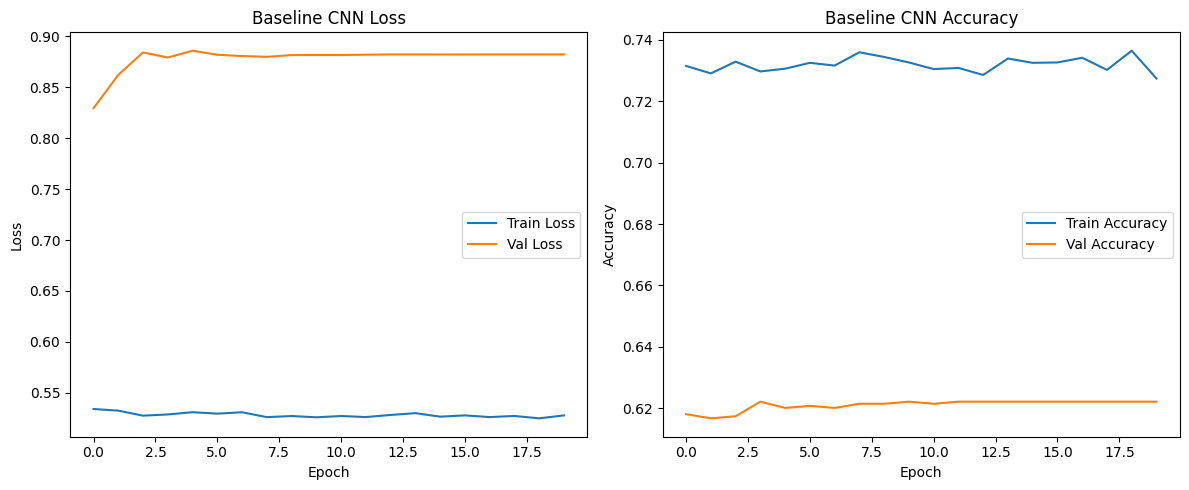

In [20]:
def plot_history(history, title):
    hist = history.history

    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.plot(hist["loss"], label="Train Loss")
    plt.plot(hist["val_loss"], label="Val Loss")
    plt.title(f"{title} Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(hist["accuracy"], label="Train Accuracy")
    plt.plot(hist["val_accuracy"], label="Val Accuracy")
    plt.title(f"{title} Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()

    plt.tight_layout()
    plt.show()

plot_history(baseline_history, "Baseline CNN")

Baseline CNN
{'model': 'Baseline CNN', 'accuracy': 0.6221166892808684, 'precision': 0.6777163904235728, 'recall': 0.49066666666666664, 'f1_score': 0.5692188708430008, 'roc_auc': np.float64(0.6725138121546961)}

Classification Report:
              precision    recall  f1-score   support

    alopecia       0.59      0.76      0.66       724
      normal       0.68      0.49      0.57       750

    accuracy                           0.62      1474
   macro avg       0.63      0.62      0.62      1474
weighted avg       0.63      0.62      0.62      1474



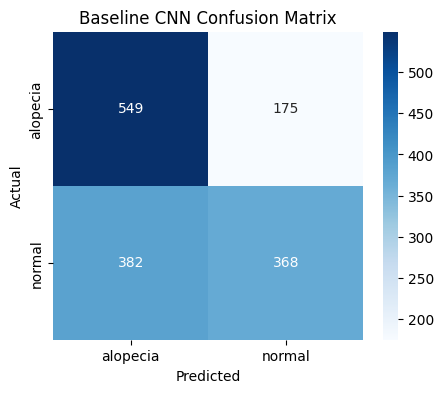

In [22]:
def evaluate_model(model, dataset, model_name):
    y_true = []
    y_prob = []

    for images, labels in dataset:
        probs = model.predict(images, verbose=0).flatten()
        y_prob.extend(probs)
        y_true.extend(labels.numpy().flatten())

    y_true = np.array(y_true).astype(int)
    y_prob = np.array(y_prob)
    y_pred = (y_prob >= 0.5).astype(int)

    metrics = {
        "model": model_name,
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1_score": f1_score(y_true, y_pred, zero_division=0),
        "roc_auc": roc_auc_score(y_true, y_prob)
    }

    print(model_name)
    print(metrics)
    print("\nClassification Report:")
    print(classification_report(y_true, y_pred, target_names=class_names))

    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=class_names,
                yticklabels=class_names)
    plt.title(f"{model_name} Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

    return metrics, y_true, y_prob, y_pred

baseline_val_metrics, _, _, _ = evaluate_model(baseline_model, val_ds, "Baseline CNN")

In [27]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam

data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.05),
    layers.RandomZoom(0.08),
    layers.RandomContrast(0.08),
])

def build_mobilenetv2_improved():
    base_model = MobileNetV2(
        weights="imagenet",
        include_top=False,
        input_shape=(224, 224, 3)
    )

    base_model.trainable = False

    inputs = layers.Input(shape=(224, 224, 3))
    x = data_augmentation(inputs)
    x = tf.keras.applications.mobilenet_v2.preprocess_input(x)
    x = base_model(x, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.45)(x)
    x = layers.Dense(128, activation="relu")(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.35)(x)
    outputs = layers.Dense(1, activation="sigmoid")(x)

    model = tf.keras.Model(inputs, outputs)

    model.compile(
        optimizer=Adam(learning_rate=1e-4),
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )

    return model, base_model

mobilenet_model, mobilenet_base = build_mobilenetv2_improved()
mobilenet_model.summary()

Model: "functional_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_7 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_2 (Sequential)       │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide_1 (TrueDivide)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract_1 (Subtract)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,427,713 (9.26 MB)

 Trainable params: 166,913 (652.00 KB)

 Non-trainable params: 2,260,800 (8.62 MB)

In [28]:
mobilenet_path = f"{MODEL_DIR}/mobilenetv2_improved_frozen.keras"

callbacks = [
    ReduceLROnPlateau(
        monitor="val_loss",
        patience=3,
        factor=0.3,
        min_lr=1e-7,
        verbose=1
    ),
    ModelCheckpoint(
        mobilenet_path,
        monitor="val_loss",
        save_best_only=True,
        verbose=1
    )
]

mobilenet_history = mobilenet_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    callbacks=callbacks
)

Epoch 1/20
245/246 ━━━━━━━━━━━━━━━━━━━━ 0s 155ms/step - accuracy: 0.5744 - loss: 0.8359
Epoch 1: val_loss improved from None to 0.53884, saving model to /content/drive/MyDrive/Alopecia_Project/outputs/models/mobilenetv2_improved_frozen.keras

Epoch 1: finished saving model to /content/drive/MyDrive/Alopecia_Project/outputs/models/mobilenetv2_improved_frozen.keras
246/246 ━━━━━━━━━━━━━━━━━━━━ 58s 205ms/step - accuracy: 0.6268 - loss: 0.7420 - val_accuracy: 0.7239 - val_loss: 0.5388 - learning_rate: 1.0000e-04
Epoch 2/20
245/246 ━━━━━━━━━━━━━━━━━━━━ 0s 146ms/step - accuracy: 0.6931 - loss: 0.6275
Epoch 2: val_loss did not improve from 0.53884
246/246 ━━━━━━━━━━━━━━━━━━━━ 43s 174ms/step - accuracy: 0.7059 - loss: 0.6041 - val_accuracy: 0.7110 - val_loss: 0.5447 - learning_rate: 1.0000e-04
Epoch 3/20
245/246 ━━━━━━━━━━━━━━━━━━━━ 0s 144ms/step - accuracy: 0.7448 - loss: 0.5495
Epoch 3: val_loss did not improve from 0.53884
246/246 ━━━━━━━━━━━━━━━━━━━━ 43s 173ms/step - accuracy: 0.7434 - los

In [29]:
mobilenet_base.trainable = True

for layer in mobilenet_base.layers[:-30]:
    layer.trainable = False

mobilenet_model.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

fine_tuned_path = f"{MODEL_DIR}/mobilenetv2_improved_finetuned.keras"

callbacks = [
    ReduceLROnPlateau(
        monitor="val_loss",
        patience=3,
        factor=0.3,
        min_lr=1e-8,
        verbose=1
    ),
    ModelCheckpoint(
        fine_tuned_path,
        monitor="val_loss",
        save_best_only=True,
        verbose=1
    )
]

mobilenet_finetune_history = mobilenet_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=15,
    callbacks=callbacks
)

Epoch 1/15
246/246 ━━━━━━━━━━━━━━━━━━━━ 0s 156ms/step - accuracy: 0.7023 - loss: 0.6174
Epoch 1: val_loss improved from None to 0.50307, saving model to /content/drive/MyDrive/Alopecia_Project/outputs/models/mobilenetv2_improved_finetuned.keras

Epoch 1: finished saving model to /content/drive/MyDrive/Alopecia_Project/outputs/models/mobilenetv2_improved_finetuned.keras
246/246 ━━━━━━━━━━━━━━━━━━━━ 57s 188ms/step - accuracy: 0.7183 - loss: 0.5848 - val_accuracy: 0.7720 - val_loss: 0.5031 - learning_rate: 1.0000e-05
Epoch 2/15
245/246 ━━━━━━━━━━━━━━━━━━━━ 0s 160ms/step - accuracy: 0.7500 - loss: 0.5458
Epoch 2: val_loss did not improve from 0.50307
246/246 ━━━━━━━━━━━━━━━━━━━━ 45s 184ms/step - accuracy: 0.7566 - loss: 0.5282 - val_accuracy: 0.7632 - val_loss: 0.5127 - learning_rate: 1.0000e-05
Epoch 3/15
245/246 ━━━━━━━━━━━━━━━━━━━━ 0s 159ms/step - accuracy: 0.7712 - loss: 0.4968
Epoch 3: val_loss did not improve from 0.50307
246/246 ━━━━━━━━━━━━━━━━━━━━ 82s 183ms/step - accuracy: 0.7742

Improved MobileNetV2 Fine-tuned
{'model': 'Improved MobileNetV2 Fine-tuned', 'accuracy': 0.7225237449118046, 'precision': 0.7364771151178918, 'recall': 0.708, 'f1_score': 0.7219578518014956, 'roc_auc': np.float64(0.8095285451197054)}

Classification Report:
              precision    recall  f1-score   support

    alopecia       0.71      0.74      0.72       724
      normal       0.74      0.71      0.72       750

    accuracy                           0.72      1474
   macro avg       0.72      0.72      0.72      1474
weighted avg       0.72      0.72      0.72      1474



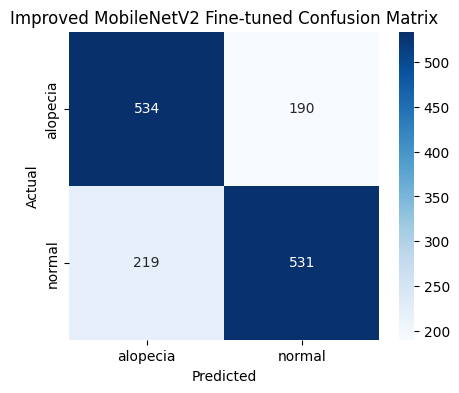

In [30]:
mobilenet_metrics, y_true_mob, y_prob_mob, y_pred_mob = evaluate_model(
    mobilenet_model,
    val_ds,
    "Improved MobileNetV2 Fine-tuned"
)

In [31]:
threshold_results = []

for threshold in np.arange(0.30, 0.71, 0.01):
    y_pred_threshold = (y_prob_mob >= threshold).astype(int)

    threshold_results.append({
        "threshold": threshold,
        "accuracy": accuracy_score(y_true_mob, y_pred_threshold),
        "precision": precision_score(y_true_mob, y_pred_threshold, zero_division=0),
        "recall": recall_score(y_true_mob, y_pred_threshold, zero_division=0),
        "f1_score": f1_score(y_true_mob, y_pred_threshold, zero_division=0)
    })

threshold_df = pd.DataFrame(threshold_results)
best_threshold_row = threshold_df.sort_values("f1_score", ascending=False).iloc[0]

display(threshold_df.sort_values("f1_score", ascending=False).head(10))

BEST_THRESHOLD = best_threshold_row["threshold"]
print("Best threshold:", BEST_THRESHOLD)
print("Best validation F1:", best_threshold_row["f1_score"])

,threshold,accuracy,precision,recall,f1_score
6,0.36,0.739484,0.713287,0.816000,0.761194
5,0.35,0.737449,0.708861,0.821333,0.760964
2,0.32,0.732022,0.697442,0.836000,0.760461
1,0.31,0.729986,0.693833,0.840000,0.759952
0,0.30,0.727951,0.689880,0.845333,0.759736
4,0.34,0.734057,0.704805,0.821333,0.758621
3,0.33,0.730665,0.699435,0.825333,0.757187
7,0.37,0.737449,0.715302,0.804000,0.757062
9,0.39,0.740163,0.722424,0.794667,0.756825
8,0.38,0.737449,0.717887,0.797333,0.755527


Best threshold: 0.36000000000000004
Best validation F1: 0.7611940298507462


              precision    recall  f1-score   support

    alopecia       0.78      0.66      0.71       724
      normal       0.71      0.82      0.76       750

    accuracy                           0.74      1474
   macro avg       0.74      0.74      0.74      1474
weighted avg       0.74      0.74      0.74      1474



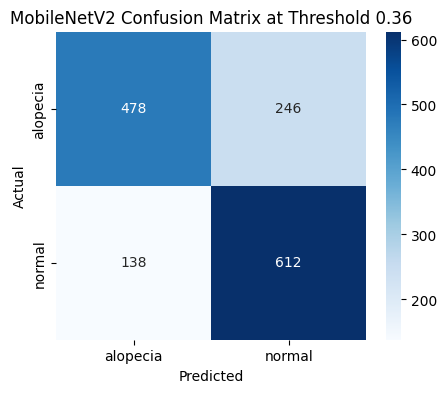

In [32]:
y_pred_best_threshold = (y_prob_mob >= BEST_THRESHOLD).astype(int)

print(classification_report(
    y_true_mob,
    y_pred_best_threshold,
    target_names=class_names
))

cm = confusion_matrix(y_true_mob, y_pred_best_threshold)

plt.figure(figsize=(5, 4))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)
plt.title(f"MobileNetV2 Confusion Matrix at Threshold {BEST_THRESHOLD:.2f}")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [38]:
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.applications.efficientnet import preprocess_input as efficientnet_preprocess
from tensorflow.keras.optimizers import Adam

data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.03),
    layers.RandomZoom(0.05),
    layers.RandomContrast(0.05),
])

def build_efficientnet_b0():
    base_model = EfficientNetB0(
        weights="imagenet",
        include_top=False,
        input_shape=(224, 224, 3)
    )

    base_model.trainable = False

    inputs = layers.Input(shape=(224, 224, 3))
    x = data_augmentation(inputs)
    x = efficientnet_preprocess(x)
    x = base_model(x, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.35)(x)
    x = layers.Dense(128, activation="relu")(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.25)(x)
    outputs = layers.Dense(1, activation="sigmoid")(x)

    model = tf.keras.Model(inputs, outputs)

    model.compile(
        optimizer=Adam(learning_rate=1e-4),
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )

    return model, base_model

efficientnet_model, efficientnet_base = build_efficientnet_b0()
efficientnet_model.summary()

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_12 (InputLayer)     │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_3 (Sequential)       │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_4      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,219,300 (16.10 MB)

 Trainable params: 166,913 (652.00 KB)

 Non-trainable params: 4,052,387 (15.46 MB)

In [39]:
efficientnet_path = f"{MODEL_DIR}/efficientnetb0_frozen.keras"

callbacks = [
    ReduceLROnPlateau(
        monitor="val_loss",
        patience=3,
        factor=0.3,
        min_lr=1e-7,
        verbose=1
    ),
    ModelCheckpoint(
        efficientnet_path,
        monitor="val_loss",
        save_best_only=True,
        verbose=1
    )
]

efficientnet_history = efficientnet_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    callbacks=callbacks
)

Epoch 1/20
136/136 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step - accuracy: 0.5991 - loss: 0.7616
Epoch 1: val_loss improved from None to 0.58355, saving model to /content/drive/MyDrive/Alopecia_Project/outputs/models/efficientnetb0_frozen.keras

Epoch 1: finished saving model to /content/drive/MyDrive/Alopecia_Project/outputs/models/efficientnetb0_frozen.keras
136/136 ━━━━━━━━━━━━━━━━━━━━ 52s 129ms/step - accuracy: 0.6504 - loss: 0.6791 - val_accuracy: 0.6582 - val_loss: 0.5835 - learning_rate: 1.0000e-04
Epoch 2/20
136/136 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step - accuracy: 0.7517 - loss: 0.5262
Epoch 2: val_loss improved from 0.58355 to 0.53791, saving model to /content/drive/MyDrive/Alopecia_Project/outputs/models/efficientnetb0_frozen.keras

Epoch 2: finished saving model to /content/drive/MyDrive/Alopecia_Project/outputs/models/efficientnetb0_frozen.keras
136/136 ━━━━━━━━━━━━━━━━━━━━ 12s 87ms/step - accuracy: 0.7661 - loss: 0.4994 - val_accuracy: 0.7048 - val_loss: 0.5379 - learning_rate: 1.0000e

In [40]:
efficientnet_base.trainable = True

for layer in efficientnet_base.layers[:-40]:
    layer.trainable = False

efficientnet_model.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

efficientnet_finetuned_path = f"{MODEL_DIR}/efficientnetb0_finetuned.keras"

callbacks = [
    ReduceLROnPlateau(
        monitor="val_loss",
        patience=3,
        factor=0.3,
        min_lr=1e-8,
        verbose=1
    ),
    ModelCheckpoint(
        efficientnet_finetuned_path,
        monitor="val_loss",
        save_best_only=True,
        verbose=1
    )
]

efficientnet_finetune_history = efficientnet_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=15,
    callbacks=callbacks
)

Epoch 1/15
136/136 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step - accuracy: 0.8243 - loss: 0.3853
Epoch 1: val_loss improved from None to 0.48831, saving model to /content/drive/MyDrive/Alopecia_Project/outputs/models/efficientnetb0_finetuned.keras

Epoch 1: finished saving model to /content/drive/MyDrive/Alopecia_Project/outputs/models/efficientnetb0_finetuned.keras
136/136 ━━━━━━━━━━━━━━━━━━━━ 37s 137ms/step - accuracy: 0.8259 - loss: 0.3851 - val_accuracy: 0.8023 - val_loss: 0.4883 - learning_rate: 1.0000e-05
Epoch 2/15
136/136 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step - accuracy: 0.8443 - loss: 0.3516
Epoch 2: val_loss improved from 0.48831 to 0.48127, saving model to /content/drive/MyDrive/Alopecia_Project/outputs/models/efficientnetb0_finetuned.keras

Epoch 2: finished saving model to /content/drive/MyDrive/Alopecia_Project/outputs/models/efficientnetb0_finetuned.keras
136/136 ━━━━━━━━━━━━━━━━━━━━ 15s 111ms/step - accuracy: 0.8537 - loss: 0.3396 - val_accuracy: 0.8164 - val_loss: 0.4813 - learning_

EfficientNetB0 Fine-tuned
{'model': 'EfficientNetB0 Fine-tuned', 'accuracy': 0.8502824858757062, 'precision': 0.8837209302325582, 'recall': 0.8216216216216217, 'f1_score': 0.8515406162464986, 'roc_auc': np.float64(0.9199424276347352)}

Classification Report:
              precision    recall  f1-score   support

    alopecia       0.82      0.88      0.85       338
      normal       0.88      0.82      0.85       370

    accuracy                           0.85       708
   macro avg       0.85      0.85      0.85       708
weighted avg       0.85      0.85      0.85       708



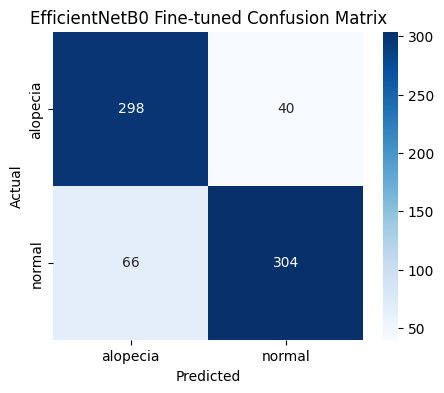

In [41]:
efficientnet_metrics, y_true_eff, y_prob_eff, y_pred_eff = evaluate_model(
    efficientnet_model,
    val_ds,
    "EfficientNetB0 Fine-tuned"
)

In [42]:
threshold_results = []

for threshold in np.arange(0.30, 0.80, 0.01):
    y_pred_t = (y_prob_eff >= threshold).astype(int)

    threshold_results.append({
        "threshold": threshold,
        "accuracy": accuracy_score(y_true_eff, y_pred_t),
        "precision": precision_score(y_true_eff, y_pred_t, zero_division=0),
        "recall": recall_score(y_true_eff, y_pred_t, zero_division=0),
        "f1_score": f1_score(y_true_eff, y_pred_t, zero_division=0)
    })

threshold_df = pd.DataFrame(threshold_results)
display(threshold_df.sort_values("f1_score", ascending=False).head(15))

BEST_THRESHOLD_EFF = threshold_df.sort_values("f1_score", ascending=False).iloc[0]["threshold"]
print("Best EfficientNetB0 threshold:", BEST_THRESHOLD_EFF)

,threshold,accuracy,precision,recall,f1_score
9,0.39,0.857345,0.862534,0.864865,0.863698
0,0.30,0.853107,0.844560,0.881081,0.862434
8,0.38,0.854520,0.857909,0.864865,0.861373
7,0.37,0.854520,0.857909,0.864865,0.861373
1,0.31,0.851695,0.844156,0.878378,0.860927
3,0.33,0.850282,0.847368,0.870270,0.858667
5,0.35,0.850282,0.849206,0.867568,0.858289
11,0.41,0.853107,0.867403,0.848649,0.857923
6,0.36,0.850282,0.851064,0.864865,0.857909
2,0.32,0.848870,0.843342,0.872973,0.857902


Best EfficientNetB0 threshold: 0.39000000000000007


              precision    recall  f1-score   support

    alopecia       0.85      0.85      0.85       338
      normal       0.86      0.86      0.86       370

    accuracy                           0.86       708
   macro avg       0.86      0.86      0.86       708
weighted avg       0.86      0.86      0.86       708



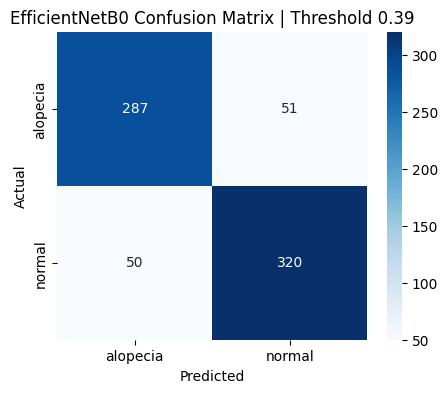

In [43]:
y_pred_eff_best = (y_prob_eff >= BEST_THRESHOLD_EFF).astype(int)

print(classification_report(
    y_true_eff,
    y_pred_eff_best,
    target_names=class_names
))

cm = confusion_matrix(y_true_eff, y_pred_eff_best)

plt.figure(figsize=(5, 4))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)
plt.title(f"EfficientNetB0 Confusion Matrix | Threshold {BEST_THRESHOLD_EFF:.2f}")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [33]:
def build_resnet50():
    base_model = ResNet50(
        weights="imagenet",
        include_top=False,
        input_shape=(224, 224, 3)
    )

    base_model.trainable = False

    inputs = layers.Input(shape=(224, 224, 3))
    x = data_augmentation(inputs)
    x = tf.keras.applications.resnet50.preprocess_input(x)
    x = base_model(x, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(0.4)(x)
    outputs = layers.Dense(1, activation="sigmoid")(x)

    model = tf.keras.Model(inputs, outputs)

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )

    return model

resnet_model = build_resnet50()
resnet_model.summary()

Model: "functional_6"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_10      │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sequential_2        │ (None, 224, 224,  │          0 │ input_layer_10[0… │
│ (Sequential)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_3          │ (None, 224, 224)  │          0 │ sequential_2[1][… │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_4          │ (None, 224, 224)  │          0 │ sequential_2[1][… │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_5          │ (None, 224, 224)  │          0 │ sequential_2[1][… │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stack_1 (Stack)     │ (None, 224, 224,  │          0 │ get_item_3[0][0], │
│                     │ 3)                │            │ get_item_4[0][0], │
│                     │                   │            │ get_item_5[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 224, 224,  │          0 │ stack_1[0][0]     │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ resnet50            │ (None, 7, 7,      │ 23,587,712 │ add_1[0][0]       │
│ (Functional)        │ 2048)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 2048)      │          0 │ resnet50[0][0]    │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_5 (Dropout) │ (None, 2048)      │          0 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_6 (Dense)     │ (None, 1)         │      2,049 │ dropout_5[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 23,589,761 (89.99 MB)

 Trainable params: 2,049 (8.00 KB)

 Non-trainable params: 23,587,712 (89.98 MB)

Epoch 1/20
246/246 ━━━━━━━━━━━━━━━━━━━━ 58s 201ms/step - accuracy: 0.5965 - loss: 0.7174 - val_accuracy: 0.6947 - val_loss: 0.5867 - learning_rate: 1.0000e-04
Epoch 2/20
246/246 ━━━━━━━━━━━━━━━━━━━━ 80s 192ms/step - accuracy: 0.6804 - loss: 0.6006 - val_accuracy: 0.7035 - val_loss: 0.5754 - learning_rate: 1.0000e-04
Epoch 3/20
246/246 ━━━━━━━━━━━━━━━━━━━━ 46s 187ms/step - accuracy: 0.7153 - loss: 0.5497 - val_accuracy: 0.7069 - val_loss: 0.5784 - learning_rate: 1.0000e-04
Epoch 4/20
246/246 ━━━━━━━━━━━━━━━━━━━━ 82s 187ms/step - accuracy: 0.7468 - loss: 0.5110 - val_accuracy: 0.7185 - val_loss: 0.5636 - learning_rate: 1.0000e-04
Epoch 5/20
246/246 ━━━━━━━━━━━━━━━━━━━━ 47s 191ms/step - accuracy: 0.7580 - loss: 0.4854 - val_accuracy: 0.7191 - val_loss: 0.5606 - learning_rate: 1.0000e-04
Epoch 6/20
246/246 ━━━━━━━━━━━━━━━━━━━━ 48s 195ms/step - accuracy: 0.7807 - loss: 0.4623 - val_accuracy: 0.7280 - val_loss: 0.5482 - learning_rate: 1.0000e-04
Epoch 7/20
246/246 ━━━━━━━━━━━━━━━━━━━━ 48s 19

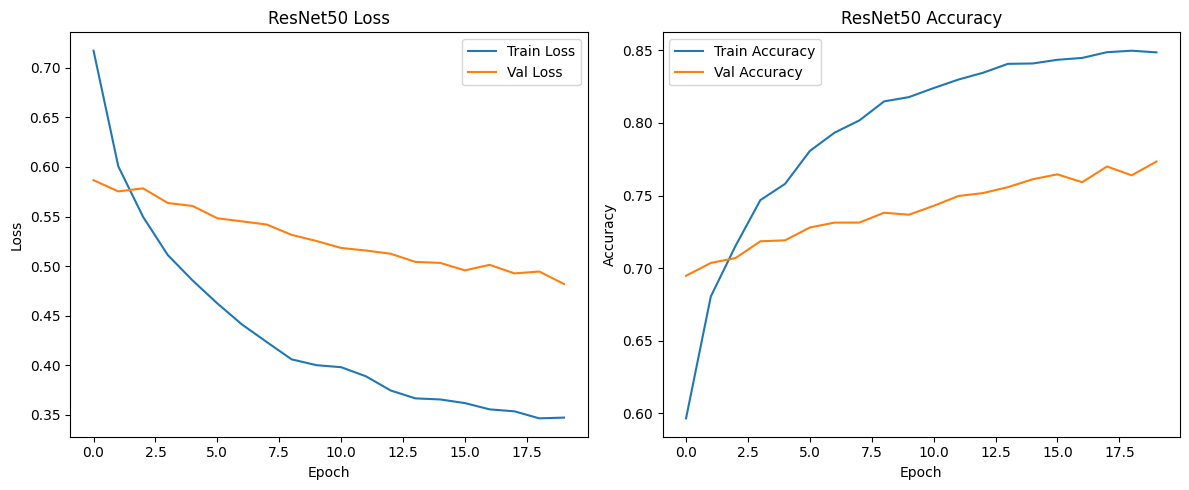

ResNet50
{'model': 'ResNet50', 'accuracy': 0.7734056987788331, 'precision': 0.8280757097791798, 'recall': 0.7, 'f1_score': 0.7586705202312138, 'roc_auc': np.float64(0.8605580110497237)}

Classification Report:
              precision    recall  f1-score   support

    alopecia       0.73      0.85      0.79       724
      normal       0.83      0.70      0.76       750

    accuracy                           0.77      1474
   macro avg       0.78      0.77      0.77      1474
weighted avg       0.78      0.77      0.77      1474



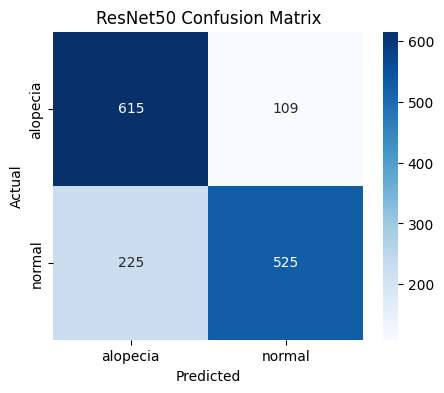

In [34]:
resnet_path = f"{MODEL_DIR}/resnet50_best.keras"

callbacks = [
    EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True),
    ReduceLROnPlateau(monitor="val_loss", patience=3, factor=0.3),
    ModelCheckpoint(resnet_path, monitor="val_loss", save_best_only=True)
]

resnet_history = resnet_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    callbacks=callbacks
)

plot_history(resnet_history, "ResNet50")
resnet_val_metrics, _, _, _ = evaluate_model(resnet_model, val_ds, "ResNet50")

In [48]:
for layer in resnet_model.layers:
    print(layer.name, type(layer))

input_layer_10 <class 'keras.src.layers.core.input_layer.InputLayer'>
sequential_2 <class 'keras.src.models.sequential.Sequential'>
resnet50 <class 'keras.src.models.functional.Functional'>
global_average_pooling2d_3 <class 'keras.src.layers.pooling.global_average_pooling2d.GlobalAveragePooling2D'>
dropout_5 <class 'keras.src.layers.regularization.dropout.Dropout'>
dense_6 <class 'keras.src.layers.core.dense.Dense'>


In [49]:
resnet_base = None

for layer in resnet_model.layers:
    if "resnet50" in layer.name.lower():
        resnet_base = layer
        break

if resnet_base is None:
    raise ValueError("Could not find ResNet50 base model inside resnet_model.")

print("Found base model:", resnet_base.name)

Found base model: resnet50


In [50]:
resnet_base.trainable = True

for layer in resnet_base.layers[:-30]:
    layer.trainable = False

resnet_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

resnet_finetuned_path = f"{MODEL_DIR}/resnet50_finetuned.keras"

callbacks = [
    ReduceLROnPlateau(
        monitor="val_loss",
        patience=3,
        factor=0.3,
        min_lr=1e-8,
        verbose=1
    ),
    ModelCheckpoint(
        resnet_finetuned_path,
        monitor="val_loss",
        save_best_only=True,
        verbose=1
    )
]

resnet_finetune_history = resnet_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=15,
    callbacks=callbacks
)

Epoch 1/15
136/136 ━━━━━━━━━━━━━━━━━━━━ 0s 191ms/step - accuracy: 0.8458 - loss: 0.3592
Epoch 1: val_loss improved from None to 0.40145, saving model to /content/drive/MyDrive/Alopecia_Project/outputs/models/resnet50_finetuned.keras

Epoch 1: finished saving model to /content/drive/MyDrive/Alopecia_Project/outputs/models/resnet50_finetuned.keras
136/136 ━━━━━━━━━━━━━━━━━━━━ 56s 244ms/step - accuracy: 0.8634 - loss: 0.3259 - val_accuracy: 0.8220 - val_loss: 0.4015 - learning_rate: 1.0000e-05
Epoch 2/15
136/136 ━━━━━━━━━━━━━━━━━━━━ 0s 174ms/step - accuracy: 0.9105 - loss: 0.2376
Epoch 2: val_loss improved from 0.40145 to 0.38260, saving model to /content/drive/MyDrive/Alopecia_Project/outputs/models/resnet50_finetuned.keras

Epoch 2: finished saving model to /content/drive/MyDrive/Alopecia_Project/outputs/models/resnet50_finetuned.keras
136/136 ━━━━━━━━━━━━━━━━━━━━ 28s 209ms/step - accuracy: 0.9181 - loss: 0.2212 - val_accuracy: 0.8446 - val_loss: 0.3826 - learning_rate: 1.0000e-05
Epoch

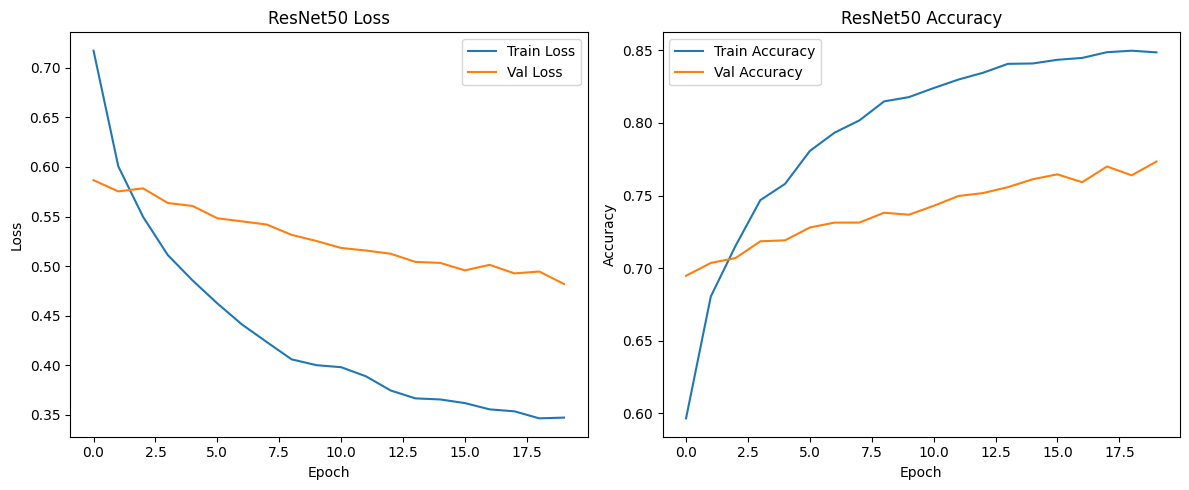

ResNet50
{'model': 'ResNet50', 'accuracy': 0.8502824858757062, 'precision': 0.8728813559322034, 'recall': 0.8351351351351352, 'f1_score': 0.8535911602209945, 'roc_auc': np.float64(0.9327442827442828)}

Classification Report:
              precision    recall  f1-score   support

    alopecia       0.83      0.87      0.85       338
      normal       0.87      0.84      0.85       370

    accuracy                           0.85       708
   macro avg       0.85      0.85      0.85       708
weighted avg       0.85      0.85      0.85       708



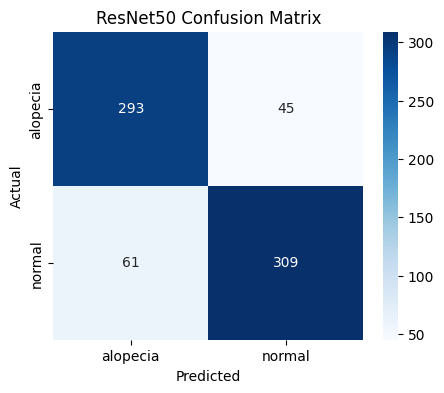

In [52]:
plot_history(resnet_history, "ResNet50")
resnet_val_metrics, _, _, _ = evaluate_model(resnet_model, val_ds, "ResNet50")

In [57]:
comparison_df = pd.DataFrame([
    baseline_val_metrics,
    mobilenet_val_metrics,
    resnet_val_metrics,

])

comparison_df = comparison_df.sort_values(by="f1_score", ascending=False)
display(comparison_df)

comparison_path = f"{METRIC_DIR}/model_comparison_validation.csv"
comparison_df.to_csv(comparison_path, index=False)

best_model_name = comparison_df.iloc[0]["model"]
print("Best model based on validation F1-score:", best_model_name)

,model,accuracy,precision,recall,f1_score,roc_auc
2,ResNet50,0.850282,0.872881,0.835135,0.853591,0.932744
1,MobileNetV2,0.725916,0.765337,0.665333,0.711840,0.790667
0,Baseline CNN,0.622117,0.677716,0.490667,0.569219,0.672514


Best model based on validation F1-score: ResNet50


In [58]:
if best_model_name == "Baseline CNN":
    best_model = baseline_model

elif best_model_name == "MobileNetV2":
    best_model = mobilenet_model

elif best_model_name == "ResNet50":
    best_model = resnet_model


else:
    raise ValueError(f"Unknown model name: {best_model_name}")

best_model_path = f"{MODEL_DIR}/best_alopecia_model.keras"
best_model.save(best_model_path)

print("Best selected model:", best_model_name)
print("Saved best model to:", best_model_path)

Best selected model: ResNet50
Saved best model to: /content/drive/MyDrive/Alopecia_Project/outputs/models/best_alopecia_model.keras


Best Model: ResNet50
{'model': 'Best Model: ResNet50', 'accuracy': 0.8801498127340824, 'precision': 0.787109375, 'recall': 0.9549763033175356, 'f1_score': 0.8629550321199143, 'roc_auc': np.float64(0.9548534180446935)}

Classification Report:
              precision    recall  f1-score   support

    alopecia       0.97      0.83      0.89       646
      normal       0.79      0.95      0.86       422

    accuracy                           0.88      1068
   macro avg       0.88      0.89      0.88      1068
weighted avg       0.90      0.88      0.88      1068



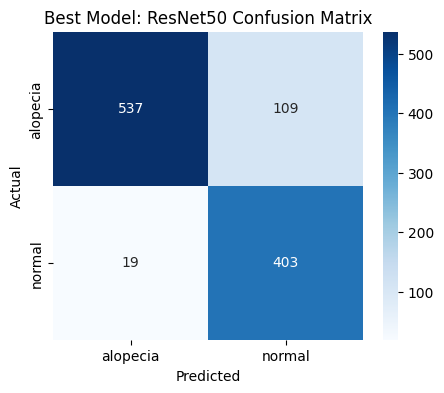

Saved final test metrics: /content/drive/MyDrive/Alopecia_Project/outputs/metrics/final_test_metrics.json


In [59]:
test_metrics, y_true, y_prob, y_pred = evaluate_model(best_model, test_ds, f"Best Model: {best_model_name}")

test_metrics_path = f"{METRIC_DIR}/final_test_metrics.json"

with open(test_metrics_path, "w") as f:
    json.dump(test_metrics, f, indent=4)

print("Saved final test metrics:", test_metrics_path)

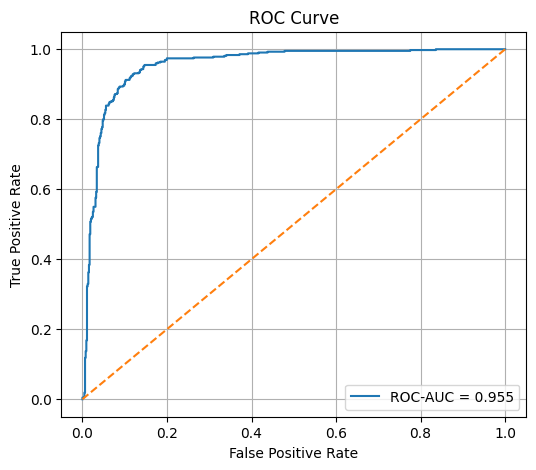

Saved ROC curve: /content/drive/MyDrive/Alopecia_Project/outputs/figures/roc_curve.png


In [60]:
fpr, tpr, _ = roc_curve(y_true, y_prob)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f"ROC-AUC = {test_metrics['roc_auc']:.3f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.title("ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.grid(True)

roc_path = f"{FIGURE_DIR}/roc_curve.png"
plt.savefig(roc_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved ROC curve:", roc_path)

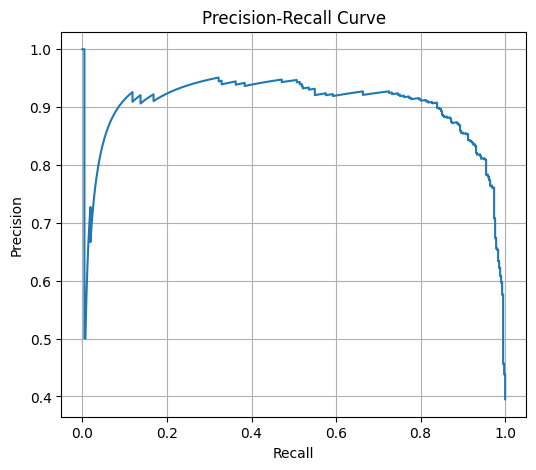

Saved PR curve: /content/drive/MyDrive/Alopecia_Project/outputs/figures/precision_recall_curve.png


In [61]:
precision, recall, _ = precision_recall_curve(y_true, y_prob)

plt.figure(figsize=(6, 5))
plt.plot(recall, precision)
plt.title("Precision-Recall Curve")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.grid(True)

pr_path = f"{FIGURE_DIR}/precision_recall_curve.png"
plt.savefig(pr_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved PR curve:", pr_path)

In [64]:
error_df = pd.DataFrame({
    "path": test_file_paths,
    "true": y_true,
    "pred": y_pred,
    "probability": y_prob
})

error_df["true_label"] = error_df["true"].apply(lambda x: class_names[int(x)])
error_df["pred_label"] = error_df["pred"].apply(lambda x: class_names[int(x)])

misclassified_df = error_df[error_df["true"] != error_df["pred"]]

print("Total misclassified:", len(misclassified_df))
display(misclassified_df.head())

error_path = f"{METRIC_DIR}/misclassified_examples.csv"
misclassified_df.to_csv(error_path, index=False)

print("Saved misclassified examples:", error_path)

Total misclassified: 128


,path,true,pred,probability,true_label,pred_label
42,/content/drive/MyDrive/Alopecia_Project/proces...,0,1,0.560501,alopecia,normal
50,/content/drive/MyDrive/Alopecia_Project/proces...,0,1,0.528715,alopecia,normal
56,/content/drive/MyDrive/Alopecia_Project/proces...,0,1,0.878133,alopecia,normal
78,/content/drive/MyDrive/Alopecia_Project/proces...,0,1,0.651700,alopecia,normal
79,/content/drive/MyDrive/Alopecia_Project/proces...,0,1,0.550665,alopecia,normal


Saved misclassified examples: /content/drive/MyDrive/Alopecia_Project/outputs/metrics/misclassified_examples.csv


In [72]:
from google.colab import files

uploaded = files.upload()

uploaded_image_path = list(uploaded.keys())[0]
print("Uploaded:", uploaded_image_path)

Saving April-Emails-Blog-2-1_fb6429c1-62e7-4b85-80e2-2a021de52233.webp to April-Emails-Blog-2-1_fb6429c1-62e7-4b85-80e2-2a021de52233.webp
Uploaded: April-Emails-Blog-2-1_fb6429c1-62e7-4b85-80e2-2a021de52233.webp


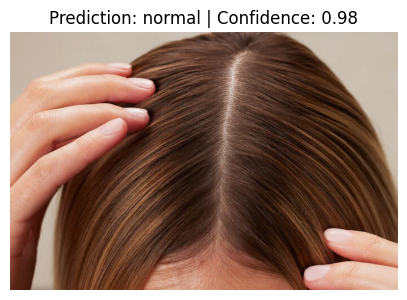

Predicted class: normal
Raw probability: 0.9784359


In [73]:
def predict_single_image(model, image_path):
    img = Image.open(image_path).convert("RGB")
    img_resized = img.resize((224, 224))

    arr = np.array(img_resized)
    arr = np.expand_dims(arr, axis=0)

    prob = model.predict(arr, verbose=0)[0][0]
    pred = 1 if prob >= 0.5 else 0

    plt.figure(figsize=(5, 5))
    plt.imshow(img)
    plt.axis("off")
    plt.title(f"Prediction: {class_names[pred]} | Confidence: {prob if pred == 1 else 1-prob:.2f}")
    plt.show()

    return class_names[pred], prob

prediction, probability = predict_single_image(best_model, uploaded_image_path)

print("Predicted class:", prediction)
print("Raw probability:", probability)